In [7]:
import os

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

## Importing Libraries

In [8]:
import torch
import matplotlib.pyplot as plt
from torchvision import transforms
from torch.utils.data import DataLoader
import torch.nn as nn
from torchvision.datasets import FashionMNIST
import torch.optim as optim

## Device

In [9]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:" , device)

Device: cpu


## Transformation

In [10]:
transforms = transforms.ToTensor()

## Data Making

In [11]:
train_data = FashionMNIST(download=True , transform=transforms , train=True , root="data")
test_data = FashionMNIST(download=True , transform=transforms , train=False , root="data")
train_data.classes

100%|██████████| 26.4M/26.4M [01:54<00:00, 230kB/s] 
100%|██████████| 29.5k/29.5k [00:00<00:00, 141kB/s]
100%|██████████| 4.42M/4.42M [00:14<00:00, 305kB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 720kB/s]


['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

## Making Data Loaders

In [12]:
train_loader = DataLoader(train_data , shuffle=True , batch_size=64)
test_loader = DataLoader(test_data , shuffle=False , batch_size=64)

## Defining Model

In [13]:
class FashionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(in_channels=1 , out_channels=32 , kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(in_channels=32 , out_channels=64 , kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.linear = nn.Sequential(
            nn.Linear(64 * 5 * 5 , 64),
            nn.ReLU(),
            nn.Linear(64 , 10)
        )
    def forward(self , x):
        x = self.cnn(x)
        x = x.view(x.size(0) , -1)
        x = self.linear(x)
        return x
model = FashionModel().to(device)

## Loss and Optimizer

In [14]:
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters() , lr = 0.001)

## Training Loop

In [15]:
epochs = 5
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for images , labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs , labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss:.4f}")

Epoch 1/5 | Loss: 508.6761
Epoch 2/5 | Loss: 334.5969
Epoch 3/5 | Loss: 292.3338
Epoch 4/5 | Loss: 261.3580
Epoch 5/5 | Loss: 239.0294


## Testing

In [16]:
model.eval()
correct = 0
total = 0
for images , labels in test_loader:
    images = images.to(device)
    labels = labels.to(device)

    outputs = model(images)
    prediction = outputs.argmax(dim=1)

    correct += (prediction == labels).sum().item()
    total += labels.size(0)

## Accuracy

In [17]:
accuracy = 100 * correct / total
print("Accuracy: " , accuracy)

Accuracy:  89.79


## Checking total Classes

In [18]:
test_data.classes

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

## Saving Model

In [19]:
torch.save(model.state_dict(), "FashionMNIST.pth")

## Visualization(Label [Number] form)m

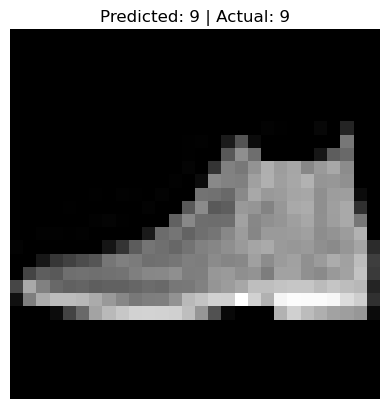

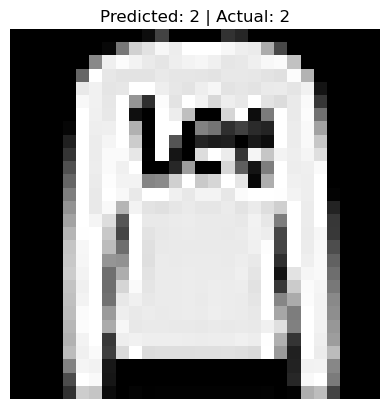

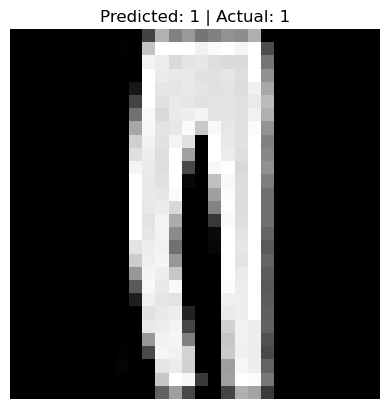

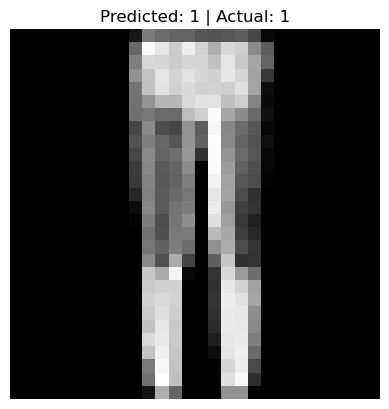

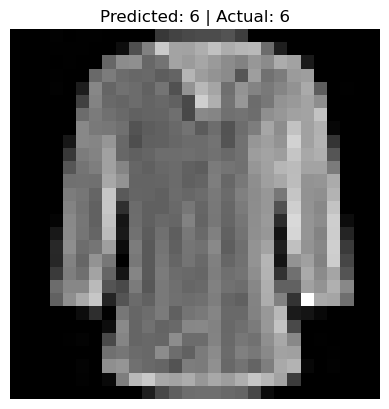

In [20]:
images , labels = next(iter(test_loader))
with torch.no_grad():
    outputs = model(images)
    prediction = outputs.argmax(dim=1)
for i in range(5):
    plt.imshow(images[i].squeeze() , cmap="grey" )
    plt.title(f"Predicted: {prediction[i].item()} | Actual: {labels[i].item()}")
    plt.axis("off")
    plt.show()
# numbers ki form mei result aye ga means k jis order mei store hai test_loder k dataset mei wesay hee un hisaab se number show hoga

## Visualization (Class Name Form)

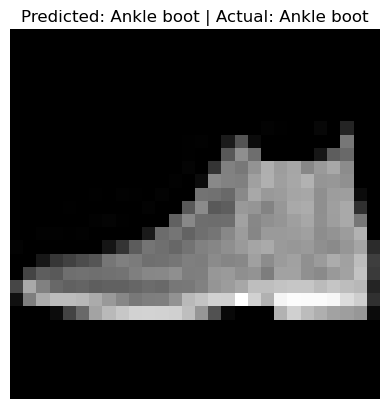

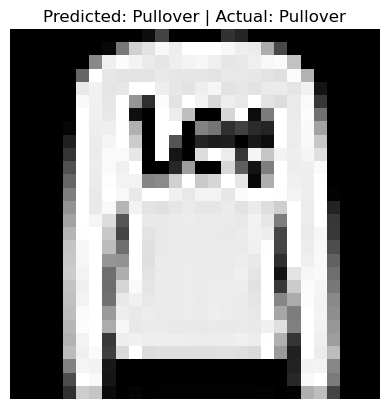

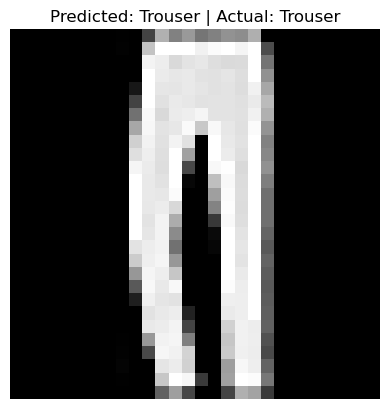

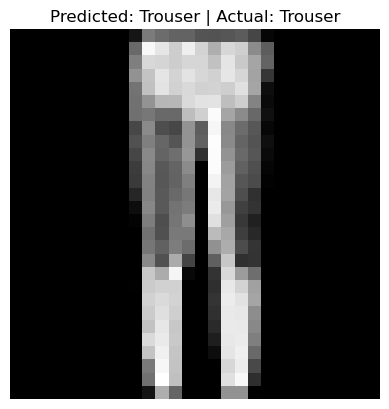

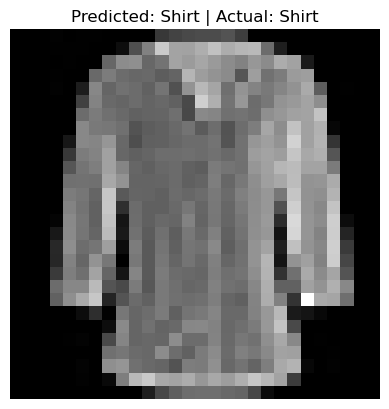

In [21]:
images , labels = next(iter(test_loader))
class_name = test_loader.dataset.classes
with torch.no_grad():
    outputs = model(images)
    prediction = outputs.argmax(dim=1)
for i in range(5):
    plt.imshow(images[i].squeeze() , cmap="grey" )
    plt.title(f"Predicted: {class_name[prediction[i]]} | Actual: {class_name[labels[i]]}")
    plt.axis("off")
    plt.show()


## Testing Own Image

In [48]:
from PIL import Image
import torchvision.transforms as transforms
import torchvision.transforms.functional as F
img = Image.open("bag.jpg").convert("L")
transform = transforms.Compose([
    transforms.Resize((28,28)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,),(0.5,))
])
img = transform(img)
img = F.invert(img)
img = img.unsqueeze(0)
print(img.shape)

torch.Size([1, 1, 28, 28])


## Visualizing my image

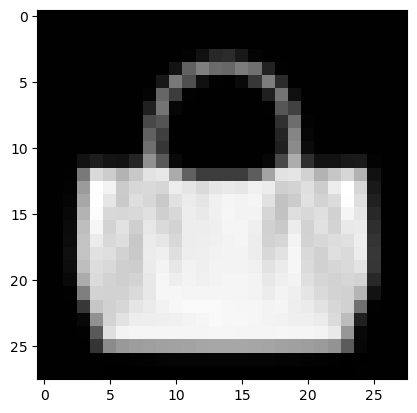

In [51]:
import matplotlib.pyplot as plt
plt.imshow(img.squeeze() , cmap="gray")
plt.show()

## Predictingm

In [50]:
model.load_state_dict(torch.load("FashionMNIST.pth"))
model.eval()
with torch.no_grad():
    output = model(img)
    pred = output.argmax(dim=1)
pred_class = pred.item()
classes = train_data.classes
print("Index:",pred_class)
print("Class:",classes[pred_class])

Index: 8
Class: Bag
